<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/NeuralNetworkApproximation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# GOOGLE COLAB NEURAL NETWORK VISUALIZATION SCRIPT
# ============================================================

# ============================================================
# INSTALLS
# ============================================================

!pip install imageio --quiet

# ============================================================
# IMPORTS
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

import imageio.v2 as imageio

import os
import shutil

from IPython.display import Image, display

# ============================================================
# DEVICE
# ============================================================

print("CUDA AVAILABLE:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# ============================================================
# USER PARAMETERS
# ============================================================

# ------------------------------------------------------------
# NUMBER OF TRAINING ITERATIONS
# ------------------------------------------------------------

NUM_ITERATIONS = 500

# ------------------------------------------------------------
# NETWORK ARCHITECTURE
#
# Example:
#
# [1, 20, 20, 20, 1]
#
# Means:
#
# input dimension  = 1
# hidden layers    = 20,20,20
# output dimension = 1
# ------------------------------------------------------------

LAYERS = [1, 20, 20, 20, 1]

# ------------------------------------------------------------
# LEARNING RATE
# ------------------------------------------------------------

LEARNING_RATE = 0.01

# ------------------------------------------------------------
# SAVE FRAME EVERY N ITERATIONS
# ------------------------------------------------------------

SAVE_EVERY = 5

# ------------------------------------------------------------
# FIGURE DPI
# ------------------------------------------------------------

FIGURE_DPI = 100

# ------------------------------------------------------------
# SHOW FULL PARAMETERS
# ------------------------------------------------------------

SHOW_FULL_PARAMETERS = True

# ============================================================
# TARGET FUNCTION
# ============================================================

def f(x):

    # --------------------------------------------------------
    # CHANGE THIS FUNCTION
    # --------------------------------------------------------

    return (
        np.sin(2*np.pi*x)
        +
        0.3*np.cos(6*np.pi*x)
    )

# ============================================================
# TRAINING DATA
# ============================================================

x_train = np.linspace(-1, 1, 400).reshape(-1,1)

y_train = f(x_train)

x_tensor = torch.tensor(
    x_train,
    dtype=torch.float32
).to(device)

y_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).to(device)

# ============================================================
# FLEXIBLE NEURAL NETWORK
# ============================================================

class SimpleNN(nn.Module):

    def __init__(self, layers):

        super().__init__()

        self.activation = nn.Tanh()

        self.layers = nn.ModuleList()

        # ----------------------------------------------------
        # CREATE LAYERS
        # ----------------------------------------------------

        for i in range(len(layers)-1):

            self.layers.append(

                nn.Linear(
                    layers[i],
                    layers[i+1]
                )

            )

    def forward(self, x):

        # ----------------------------------------------------
        # HIDDEN LAYERS
        # ----------------------------------------------------

        for layer in self.layers[:-1]:

            x = self.activation(layer(x))

        # ----------------------------------------------------
        # FINAL LAYER
        # ----------------------------------------------------

        x = self.layers[-1](x)

        return x

# ============================================================
# CREATE MODEL
# ============================================================

model = SimpleNN(LAYERS).to(device)

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.MSELoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = "frames"

# ------------------------------------------------------------
# CLEAR OLD DIRECTORY
# ------------------------------------------------------------

if os.path.exists(output_dir):

    shutil.rmtree(output_dir)

os.makedirs(output_dir)

# ============================================================
# TRAINING LOOP
# ============================================================

for iteration in range(NUM_ITERATIONS):

    # ========================================================
    # FORWARD PASS
    # ========================================================

    y_pred = model(x_tensor)

    # ========================================================
    # LOSS
    # ========================================================

    loss = criterion(y_pred, y_tensor)

    # ========================================================
    # BACKPROPAGATION
    # ========================================================

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # ========================================================
    # PRINT LOSS
    # ========================================================

    print(
        f"Iteration {iteration:04d}"
        f" | Loss = {loss.item():.10f}"
    )

    # ========================================================
    # SAVE FRAME
    # ========================================================

    if iteration % SAVE_EVERY == 0:

        # ----------------------------------------------------
        # EVALUATE NETWORK
        # ----------------------------------------------------

        with torch.no_grad():

            y_nn = model(x_tensor).cpu().numpy()

        # ----------------------------------------------------
        # CREATE FIGURE
        # ----------------------------------------------------

        fig = plt.figure(figsize=(14,10))

        # ====================================================
        # TOP PANEL
        # ====================================================

        ax1 = plt.subplot(2,1,1)

        ax1.plot(
            x_train,
            y_train,
            linewidth=3,
            label="True Function"
        )

        ax1.plot(
            x_train,
            y_nn,
            '--',
            linewidth=3,
            label="NN Approximation"
        )

        ax1.set_title(
            f"Iteration {iteration}",
            fontsize=18
        )

        ax1.set_xlabel("x")

        ax1.set_ylabel("f(x)")

        ax1.grid(True)

        ax1.legend()

        # ====================================================
        # BOTTOM PANEL
        # ====================================================

        ax2 = plt.subplot(2,1,2)

        ax2.axis("off")

        parameter_text = ""

        # ----------------------------------------------------
        # NETWORK INFO
        # ----------------------------------------------------

        parameter_text += (
            f"Architecture: {LAYERS}\n"
        )

        parameter_text += (
            f"Loss = {loss.item():.10f}\n\n"
        )

        # ----------------------------------------------------
        # PRINT PARAMETERS
        # ----------------------------------------------------

        if SHOW_FULL_PARAMETERS:

            for name, param in model.named_parameters():

                parameter_text += f"{name}\n"

                values = (
                    param
                    .detach()
                    .cpu()
                    .numpy()
                )

                parameter_text += np.array2string(
                    values,
                    precision=3,
                    suppress_small=True
                )

                parameter_text += "\n\n"

        else:

            for name, param in model.named_parameters():

                values = (
                    param
                    .detach()
                    .cpu()
                    .numpy()
                )

                parameter_text += (
                    f"{name}\n"
                )

                parameter_text += (
                    f"shape = {values.shape}\n"
                )

                parameter_text += (
                    f"mean  = {values.mean():.5f}\n"
                )

                parameter_text += (
                    f"std   = {values.std():.5f}\n"
                )

                parameter_text += (
                    f"min   = {values.min():.5f}\n"
                )

                parameter_text += (
                    f"max   = {values.max():.5f}\n\n"
                )

        # ----------------------------------------------------
        # DISPLAY TEXT
        # ----------------------------------------------------

        ax2.text(
            0.01,
            0.99,
            parameter_text,
            va='top',
            fontsize=8,
            family='monospace'
        )

        plt.tight_layout()

        # ----------------------------------------------------
        # SAVE FIGURE
        # ----------------------------------------------------

        filename = (
            f"{output_dir}/frame_{iteration:05d}.png"
        )

        plt.savefig(
            filename,
            dpi=FIGURE_DPI
        )

        plt.close()

CUDA AVAILABLE: True
GPU: Tesla T4
Using device: cuda
Iteration 0000 | Loss = 0.5597518682


/tmp/ipykernel_22477/698554954.py:399: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Iteration 0001 | Loss = 0.5309190154
Iteration 0002 | Loss = 0.4942216277
Iteration 0003 | Loss = 0.4796881080
Iteration 0004 | Loss = 0.4773178697
Iteration 0005 | Loss = 0.4795385599
Iteration 0006 | Loss = 0.4881799221
Iteration 0007 | Loss = 0.4843811691
Iteration 0008 | Loss = 0.4766485393
Iteration 0009 | Loss = 0.4738249183
Iteration 0010 | Loss = 0.4735760391
Iteration 0011 | Loss = 0.4740555882
Iteration 0012 | Loss = 0.4761504531
Iteration 0013 | Loss = 0.4782341719
Iteration 0014 | Loss = 0.4778707922
Iteration 0015 | Loss = 0.4757766128
Iteration 0016 | Loss = 0.4738998413
Iteration 0017 | Loss = 0.4724820256
Iteration 0018 | Loss = 0.4710158706
Iteration 0019 | Loss = 0.4703141749
Iteration 0020 | Loss = 0.4711075425
Iteration 0021 | Loss = 0.4719760716
Iteration 0022 | Loss = 0.4716500342
Iteration 0023 | Loss = 0.4708651602
Iteration 0024 | Loss = 0.4700414240
Iteration 0025 | Loss = 0.4688822031
Iteration 0026 | Loss = 0.4680283964
Iteration 0027 | Loss = 0.4680312574
I


GIF CREATED


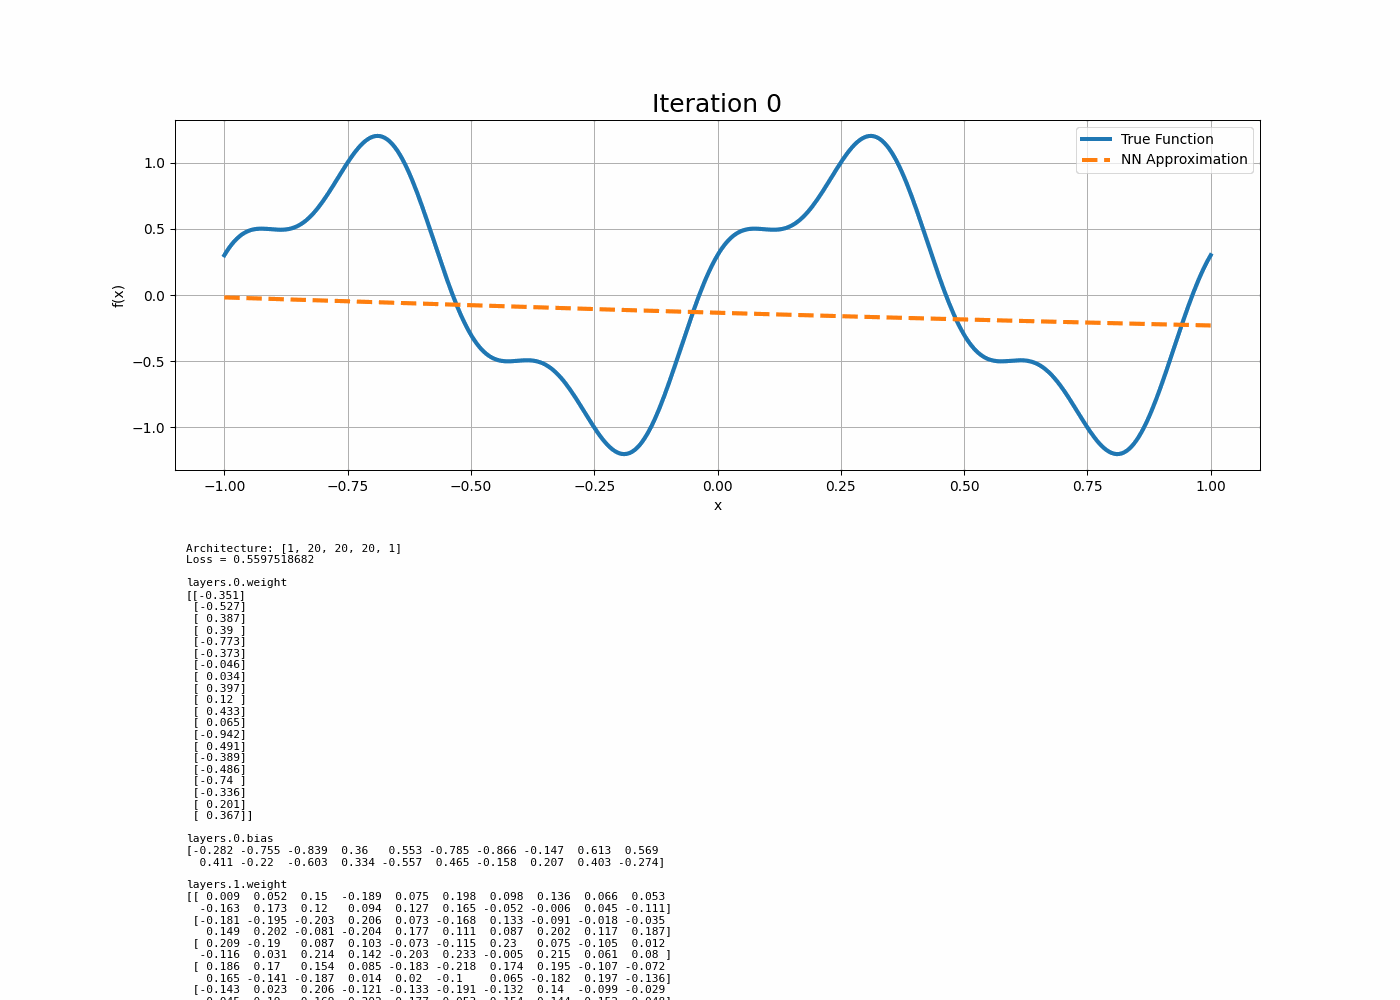

In [ ]:
# ============================================================
# CREATE GIF
# ============================================================

gif_filename = "training_evolution.gif"

images = []

frame_numbers = range(
    0,
    NUM_ITERATIONS,
    SAVE_EVERY
)

for iteration in frame_numbers:

    filename = (
        f"{output_dir}/frame_{iteration:05d}.png"
    )

    images.append(
        imageio.imread(filename)
    )

# ------------------------------------------------------------
# SAVE GIF
# ------------------------------------------------------------

imageio.mimsave(
    gif_filename,
    images,
    fps=5
)

print("\nGIF CREATED")

# ============================================================
# DISPLAY GIF
# ============================================================

display(Image(filename=gif_filename))